## Sympy

The ODE is:


Eq(D*Derivative(p(x), (x, 2)) - v*Derivative(p(x), x), 0)

Eq(10*D*S*Derivative(p(x), x) + D*Derivative(p(x), (x, 2)) - v*Derivative(p(x), x), 0)


The general solution is:


Eq(p(x), C1 + C2*exp(v*x/D))

...

{C1: -1/(exp(v/D) - 1), C2: 1/(exp(v/D) - 1)}

{C1: exp(10*S)/(exp(10*S) - exp(v/D)), C2: -exp(10*S)/(exp(10*S) - exp(v/D))}


The final solution is:


(1 - exp(v*x/D))/(1 - exp(v/D))

(exp(10*S*x) - exp(v*x/D))*exp(10*S*(1 - x))/(exp(10*S) - exp(v/D))

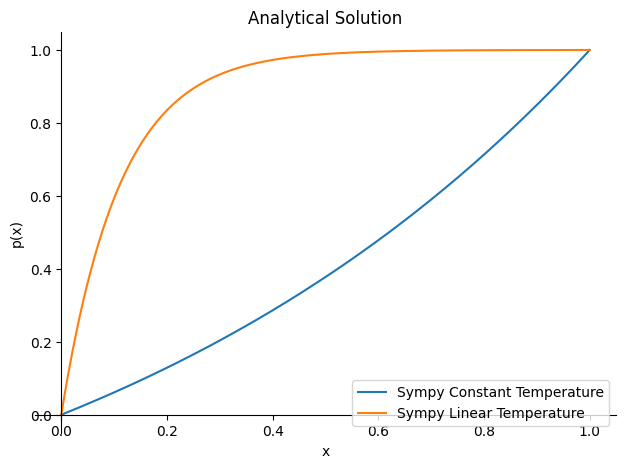

In [1]:
import sympy as sp

x_sym = sp.symbols('x')
D, v, S = sp.symbols('D v S')
p_sympy_const = sp.Function('p')(x_sym)
p_sympy_lin = sp.Function('p')(x_sym)

T1 = 300
T2 = T1 + 10 * x_sym

ode_const = sp.Eq(D * sp.diff(p_sympy_const, x_sym, 2) - v * sp.diff(p_sympy_const, x_sym) + D * S * sp.diff(p_sympy_const * sp.diff(T1, x_sym), x_sym), 0)
ode_lin = sp.Eq(D * sp.diff(p_sympy_lin, x_sym, 2) - v * sp.diff(p_sympy_lin, x_sym) + D * S * sp.diff(p_sympy_lin * sp.diff(T2, x_sym), x_sym), 0)
print("The ODE is:")
display(sp.simplify(ode_const))
display(sp.simplify(ode_lin))

solution_const = sp.dsolve(ode_const, p_sympy_const)
solution_lin = sp.dsolve(ode_lin, p_sympy_lin)

print("\nThe general solution is:")
display(solution_const)
display(solution_lin)

p_sol_const = solution_const.rhs
p_sol_lin = solution_lin.rhs
bc1 = sp.Eq(p_sol_const.subs(x_sym, 0), 0)  
bc2 = sp.Eq(p_sol_const.subs(x_sym, 1), 1)  
bc3 = sp.Eq(p_sol_lin.subs(x_sym, 0), 0)  
bc4 = sp.Eq(p_sol_lin.subs(x_sym, 1), 1)

C1, C2 = sp.symbols('C1 C2')
constants1 = sp.solve([bc1, bc2], (C1, C2))
constants2 = sp.solve([bc3, bc4], (C1, C2))
print("\nThe constants are:")
display(sp.simplify(constants1))
display(sp.simplify(constants2))

p_sympy_const = sp.simplify(p_sol_const.subs(constants1))
p_sympy_lin = sp.simplify(p_sol_lin.subs(constants2))
print("\nThe final solution is:")
display(p_sympy_const)
display(p_sympy_lin)

p_sympy_func_const = sp.lambdify(x_sym, p_sympy_const.subs({D:1.0, v:1.0, S:1.0}), "numpy") 
p_sympy_func_lin = sp.lambdify(x_sym, p_sympy_lin.subs({D:1.0, v:1.0, S:1.0}), "numpy")

sympy_plot = sp.plot(p_sympy_const.subs({D:1.0, v:1.0, S:1.0}), p_sympy_lin.subs({D:1.0, v:1.0, S:1.0}), (x_sym, 0, 1), title='Analytical Solution', xlabel='x', ylabel='p(x)', legend=True, show=False)
sympy_plot[0].label = 'Sympy Constant Temperature' 
sympy_plot[1].label = 'Sympy Linear Temperature'
sympy_plot.show()

## Fipy 

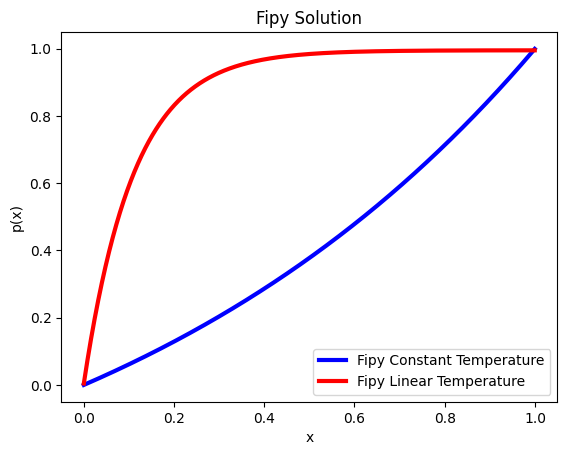

In [2]:
from fipy import CellVariable, FaceVariable, Grid1D, TransientTerm, DiffusionTerm, PowerLawConvectionTerm, Viewer
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

L = 1.0  
nx = 1000  
dx = L / nx  
mesh = Grid1D(nx=nx, dx=dx)

D, v, S = 1.0, 1.0, 1.0 

x = mesh.cellCenters[0]

T1 = CellVariable(name="Temperature", mesh=mesh, value=300.0)
T2 = CellVariable(name="Temperature", mesh=mesh, value=T1 + 10 * x)

p_const = CellVariable(name="Carrier Concentration", mesh=mesh, value=0.0)
p_lin = CellVariable(name="Carrier Concentration", mesh=mesh, value=0.0)

p_const.constrain(0.0, mesh.facesLeft)
p_const.constrain(1.0, mesh.facesRight)
p_lin.constrain(0.0, mesh.facesLeft)
p_lin.constrain(1.0, mesh.facesRight)

v = FaceVariable(mesh=mesh, rank = 1, value=1.0)

eq_const = (DiffusionTerm(coeff=D)  == PowerLawConvectionTerm(coeff=(v),) - PowerLawConvectionTerm(coeff = D * S * T1.faceGrad))
eq_lin = (DiffusionTerm(coeff=D)  == PowerLawConvectionTerm(coeff=(v),) - PowerLawConvectionTerm(coeff = D * S * T2.faceGrad))
eq_const.solve(var=p_const)
eq_lin.solve(var=p_lin)

plt.plot(x, p_const.value, label='Fipy Constant Temperature', color='blue', linewidth=3)
plt.plot(x, p_lin.value, label='Fipy Linear Temperature', color='red', linewidth=3)
plt.title('Fipy Solution')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

## Error Calculation

In [3]:
error_const = np.abs(p_const.value - p_sympy_func_const(x.value))
print("Maximum error_const:", np.max(error_const))
print("Mean error_const:", np.mean(error_const))
print("L2 error_const:", np.sqrt(np.mean(error_const**2)))
print ("\n")
error_lin = np.abs(p_lin.value - p_sympy_func_lin(x.value))
print("Maximum error_lin:", np.max(error_lin))
print("Mean error_lin:", np.mean(error_lin))
print("L2 error_lin:", np.sqrt(np.mean(error_lin**2)))

Maximum error_const: 1.0055268784281424e-08
Mean error_const: 6.600597355297007e-09
L2 error_const: 7.263292083160902e-09


Maximum error_lin: 0.004976358141616899
Mean error_lin: 0.004423154505515251
L2 error_lin: 0.004543018853944201


## Plot Comparison


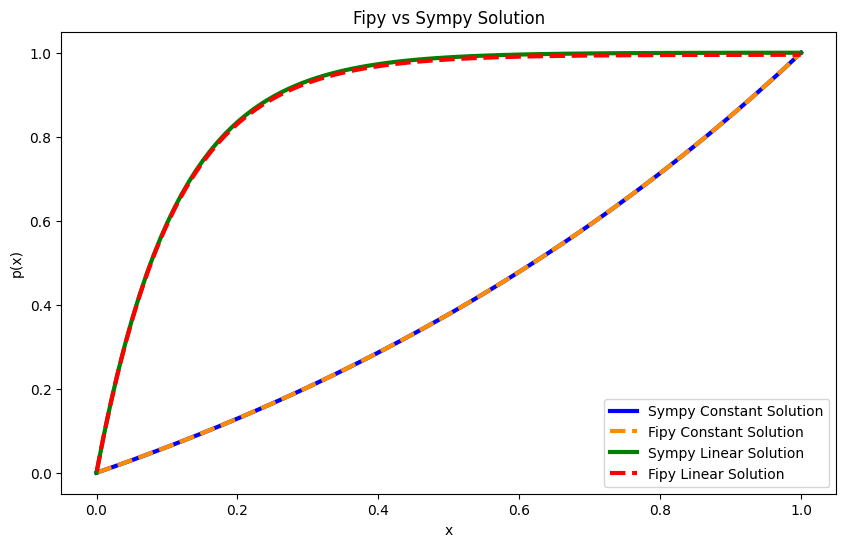

In [4]:
import matplotlib.pyplot as plt

x_exact = np.linspace(0, 1, 100)
p_exact_const = p_sympy_func_const(x_exact)
p_exact_lin = p_sympy_func_lin(x_exact)

plt.figure(figsize=(10, 6))

plt.plot(x_exact, p_exact_const, label='Sympy Constant Solution', color='blue', linewidth=3)
plt.plot(x.value, p_const.value, '--', label='Fipy Constant Solution', color='darkorange', linewidth=3)
plt.plot(x_exact, p_exact_lin, label='Sympy Linear Solution', color='green', linewidth=3)
plt.plot(x.value, p_lin.value, '--', label='Fipy Linear Solution', color='red', linewidth=3)
plt.title('Fipy vs Sympy Solution')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

{C1: -1/(exp(v/D) - 1), C2: 1/(exp(v/D) - 1)}

Constant Temperature: T = 300
LHS:


0.581976706869326*exp(1.0*x)

RHS:


0.581976706869326*exp(1.0*x)


Linear Temperature: T = 300 + 10x
LHS:


47.1401132564154*exp(-9.0*x)

RHS:


47.1401132564154*exp(-9.0*x)

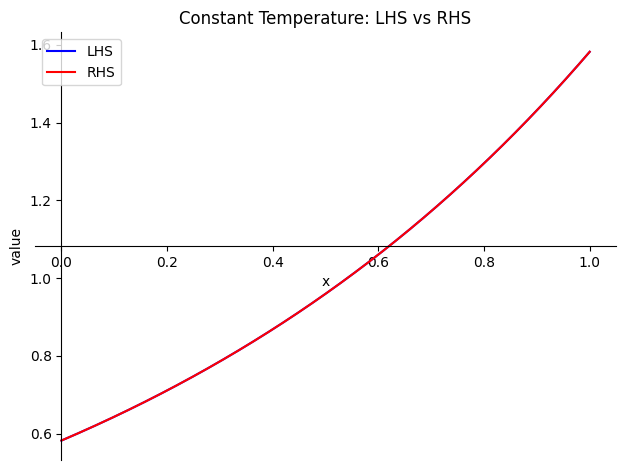

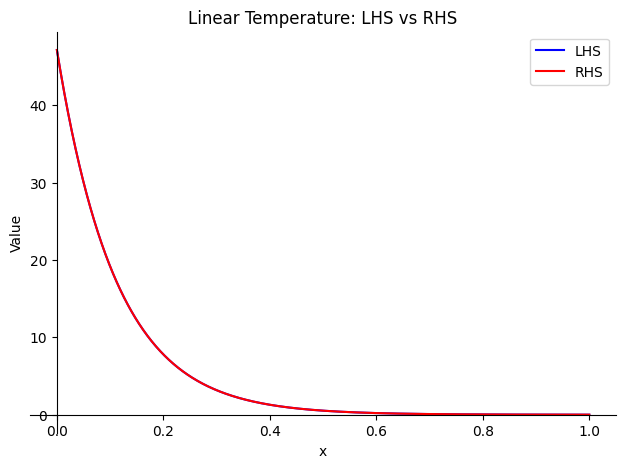

In [13]:
import sympy as sp

x = sp.symbols('x')
D, v, S = sp.symbols('D v S')

values = {D: 1.0, v: 1.0, S: 1.0}

T_const = 300
T_lin = T_const + 10 * x

p = sp.Function('p')(x)

ode_const = sp.Eq(D * sp.diff(p, x, 2) - v * sp.diff(p, x) + D * S * sp.diff(p * sp.diff(T_const, x), x), 0)
ode_lin = sp.Eq(D * sp.diff(p, x, 2) - v * sp.diff(p, x) + D * S * sp.diff(p * sp.diff(T_lin, x), x), 0)

solution_const = sp.dsolve(ode_const, p)
solution_lin = sp.dsolve(ode_lin, p)

solution_const = solution_const.rhs
solution_lin = solution_lin.rhs

C1, C2 = sp.symbols('C1 C2')
bc1 = sp.Eq(solution_const.subs(x, 0), 0)
bc2 = sp.Eq(solution_const.subs(x, 1), 1)
constants = sp.solve([bc1, bc2], (C1, C2))
display(sp.simplify(constants))

p_const_final = sp.simplify(solution_const.subs(constants))
p_lin_final = sp.simplify(solution_lin.subs(constants))

dpdx_const = sp.diff(p_const_final, x)
dp2dx2_const = sp.diff(p_const_final, x, 2)

LHS_const = sp.simplify(dp2dx2_const)
RHS_const = sp.simplify((v/D - S * sp.diff(T_const, x)) * dpdx_const)

dpdx_lin = sp.diff(p_lin_final, x)
dp2dx2_lin = sp.diff(p_lin_final, x, 2)

LHS_lin = sp.simplify(dp2dx2_lin)
RHS_lin = sp.simplify((v/D - S * sp.diff(T_lin, x)) * dpdx_lin)

LHS_const_num = sp.simplify(LHS_const.subs(values))
RHS_const_num = sp.simplify(RHS_const.subs(values))

LHS_lin_num = sp.simplify(LHS_lin.subs(values))
RHS_lin_num = sp.simplify(RHS_lin.subs(values))

print("Constant Temperature: T = 300")
print("LHS:")
display(LHS_const_num)
print("RHS:")
display(RHS_const_num)

print("\nLinear Temperature: T = 300 + 10x")
print("LHS:")
display(LHS_lin_num)
print("RHS:")
display(RHS_lin_num)

plot_const = sp.plot(LHS_const_num, RHS_const_num, (x, 0, 1), title="Constant Temperature: LHS vs RHS", xlabel = "x", ylabel = "value", legend = True, show = False)
plot_const[0].label = "LHS"
plot_const[1].label = "RHS"
plot_const[0].line_color = "blue"
plot_const[1].line_color = "red"
plot_const[1].line_style = "--"
plot_const.show()

plot_linear = sp.plot(LHS_lin_num, RHS_lin_num, (x, 0, 1), title="Linear Temperature: LHS vs RHS", xlabel="x", ylabel="Value", legend=True, show=False)
plot_linear[0].label = "LHS"
plot_linear[1].label = "RHS"
plot_linear[0].line_color = "blue"
plot_linear[1].line_color = "red"
plot_linear[1].line_style = "--"
plot_linear.show()


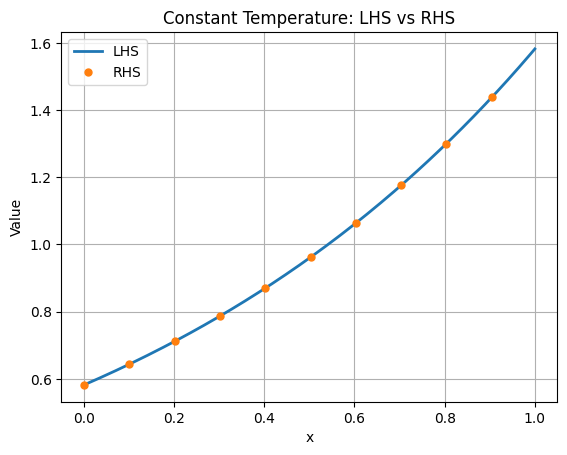

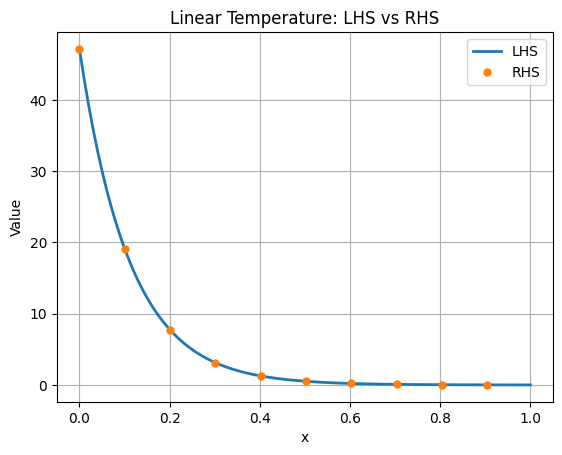

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

LHS_const_func = sp.lambdify(x, LHS_const_num, "numpy")
RHS_const_func = sp.lambdify(x, RHS_const_num, "numpy")

LHS_lin_func = sp.lambdify(x, LHS_lin_num, "numpy")
RHS_lin_func = sp.lambdify(x, RHS_lin_num, "numpy")

x_values = np.linspace(0, 1, 200)

plt.figure()

plt.plot(x_values, LHS_const_func(x_values), label="LHS", linewidth=2)
plt.plot(x_values[::20], RHS_const_func(x_values[::20]), "o", label="RHS", markersize=5)
plt.xlabel("x")
plt.ylabel("Value")
plt.title("Constant Temperature: LHS vs RHS")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x_values, LHS_lin_func(x_values), label="LHS", linewidth=2)
plt.plot(x_values[::20], RHS_lin_func(x_values[::20]), "o", label="RHS", markersize=5)
plt.xlabel("x")
plt.ylabel("Value")
plt.title("Linear Temperature: LHS vs RHS")
plt.legend()
plt.grid(True)
plt.show()

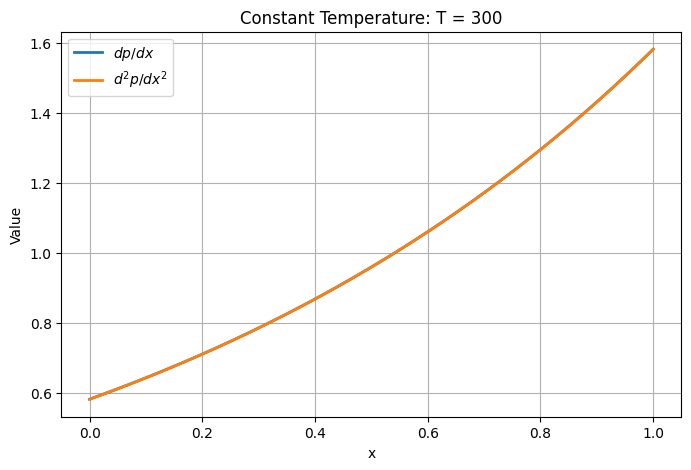

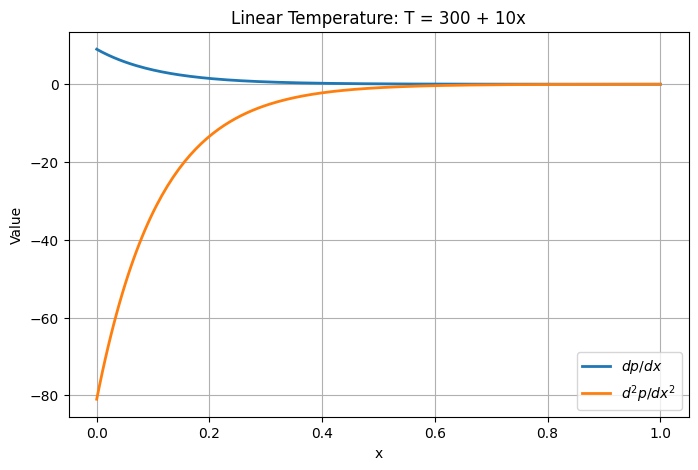

In [25]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.symbols('x')
diffusion = 1.0
velocity = 1.0
soret = 1.0

p = sp.Function('p')(x)

T_c = 300
T_l = 300 + 10 * x

ode_c = sp.Eq(diffusion * sp.diff(p, x, 2) - velocity * sp.diff(p,x) + diffusion * soret * sp.diff(p * sp.diff(T_c, x), x), 0)
ode_l = sp.Eq(diffusion * sp.diff(p, x, 2) - velocity * sp.diff(p, x) + diffusion * soret * sp.diff(p * sp.diff(T_l, x), x), 0)

sol_c = sp.dsolve(ode_c, p).rhs
sol_l = sp.dsolve(ode_l, p).rhs

C1, C2 = sp.symbols('C1 C2')

constants_c = sp.solve([sp.Eq(sol_c.subs(x, 0), 0), (sp.Eq(sol_c.subs(x, 1), 1))], (C1, C2))
constants_l = sp.solve([sp.Eq(sol_l.subs(x, 0), 0), (sp.Eq(sol_l.subs(x, 1), 1))], (C1, C2))

p_c = sp.simplify(sol_c.subs(constants_c))
p_l = sp.simplify(sol_l.subs(constants_l))

dpdx_c = sp.diff(p_c, x)
dp2dx2_c = sp.diff(p_c, x, 2)

dpdx_l = sp.diff(p_l, x)
dp2dx2_l = sp.diff(p_l, x, 2)

x_values = np.linspace(0, 1, 200)

dpdx_c_func = sp.lambdify(x, dpdx_c, 'numpy')
dp2dx2_c_func = sp.lambdify(x, dp2dx2_c, 'numpy')

dpdx_l_func = sp.lambdify(x, dpdx_l, 'numpy')
dp2dx2_l_func = sp.lambdify(x, dp2dx2_l, 'numpy')

plt.figure(figsize=(8, 5))
plt.plot(x_values, dpdx_c_func(x_values), label=r"$dp/dx$", linewidth=2)
plt.plot(x_values, dp2dx2_c_func(x_values), label=r"$d^2p/dx^2$", linewidth=2)
plt.xlabel("x")
plt.ylabel("Value")
plt.title("Constant Temperature: T = 300")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_values, dpdx_l_func(x_values), label=r"$dp/dx$", linewidth=2)
plt.plot(x_values, dp2dx2_l_func(x_values), label=r"$d^2p/dx^2$", linewidth=2)
plt.xlabel("x")
plt.ylabel("Value")
plt.title("Linear Temperature: T = 300 + 10x")
plt.legend()
plt.grid(True)
plt.show()